# Demonstration of the functionality of the christoffel module

We demonstrate the functionality of the Christoffel module by using the elastic tensor of forsterite olivine at room conditions.

In [1]:
# TO REMOVE
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# Make the pyrockwave package importable from the notebooks/ folder
sys.path.insert(0, os.path.join("..", "src"))

In [2]:
# PyRockWave imports
from pyrockwave.christoffel import phase_seismic_properties, full_seismic_properties
from pyrockwave.utils.coordinates import equispaced_S2_grid, cart2sph
from pyrockwave.plotting.plots import culled_quiver
import pyrockwave.utils.tensor_tools as tt

The christoffel module has two main functions: ``phase_seismic_properties`` and ``full_seismic_properties``. The former compute phase velocities (Vp, Vs1, Vs2), Vp/Vs ratios and shear-wave splitting for an array of propagation directions while the latter compute phase and group velocities along with other parameters such as enhancement factors and power flow angles. We will explain the meaning of these terms later. We will also explain when you need to calculate phase or group velocities.

## Input data

The data required to estimate the seismic properties in any arbitrary direction of a given material using the Christoffel equation are the density and the stiffness tensor of the material.

The stiffness tensor $C_{ijkl}$ is a fundamental material property that generalises Hooke's law in three dimensions by relating strains to stresses within the elastic regime. This is usually abbreviated to a 6x6 matrix ($C_{ij}$) using Voigt notation with values given in $GPa$. The density is typically expressed in *gcm-3*.

In [3]:
# set the elastic tensor and density of forsterite measured by Mao et al. (2015) EPLS at room conditions
Cij = np.array([[320.2,  71.0,  71.0,   0. ,   0. ,   0. ],
                [ 71.0, 196.5,  76.0,   0. ,   0. ,   0. ],
                [ 71.0,  76.0, 232.3,   0. ,   0. ,   0. ],
                [  0. ,   0. ,   0. ,  63.2,   0. ,   0. ],
                [  0. ,   0. ,   0. ,   0. ,  76.6,   0. ],
                [  0. ,   0. ,   0. ,   0. ,   0. ,  79.7]])

density_gcm3 = 3.300

The seismic properties of most materials are anisotropic, i.e. they depend on direction. Consequently, we also need to provide as input the propagation directions of interest, typically , denoted as wave vectors or $\vec{q}$. To observe anisotropy in 3D, we need to estimate the properties along at least three perpendicular directions, or more typically along a set of equispaced spherical grid directions. Wavevectors can be defined in spherical coordinates (polar and azimuthal angles) or in Cartesian coordinates ($x, y, z$) normalised to the unit sphere (i.e. vectors of size 1 or unit vectors).The submodule ``utils.coordinates`` contains several functions to generate an equispaced spherical grid of wavevectors, and to convert between spherical and Cartesian coordinates, and vice versa.

In this case, we proceed as follows:

- Create a set of equispaced wavevectors in spherical coordinates.
- Convert from spherical to 3D Cartesian unit vectors (for plotting).

In [4]:
# create a set of equispaced wavevectors in spherical coordinates using radians
wavevectors = equispaced_S2_grid(ang_spacing_deg=2, include_axes=True)

In [5]:
wavevectors.shape

(10319, 3)

In [6]:
# select a subset of wavevectors for plotting the Vs polarizations:
# keep the fine-grid points closest to a coarse (~10 deg) reference
# grid so the arrows stay approximately equispaced at any density ratio
coarse_grid = equispaced_S2_grid(ang_spacing_deg=10, include_axes=True)
subset = np.unique(cKDTree(wavevectors).query(coarse_grid)[1])
subset.shape

(419,)

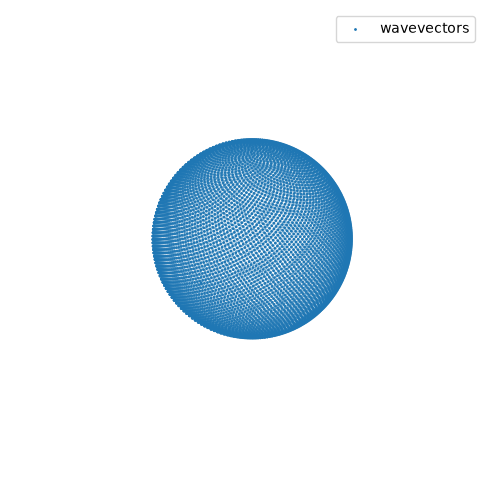

In [7]:
# plot to test
fig1, ax = plt.subplots(subplot_kw={"projection": "3d"}, constrained_layout=True)

ax.scatter(
    wavevectors[:, 0], wavevectors[:, 1], wavevectors[:, 2], s=1, label="wavevectors"
)

ax.axis("off")
ax.axis("equal")
ax.legend()

## Compute phase velocities

TODO

In [8]:
velocities, polarization = phase_seismic_properties(
    Cij=Cij,
    density_gcm3=density_gcm3,
    wavevectors=wavevectors
)

In [9]:
# P-wave polarizations, sign-flipped to point outward
dots = np.einsum("ij,ij->i", polarization[:, 2], wavevectors)
p_polarization = polarization[:, 2] * np.where(dots < 0, -1.0, 1.0)[:, None]

In [10]:
velocities

,azimuths_deg,polar_deg,qx,qy,qz,Vs2_phase_kms,Vs1_phase_kms,Vp_phase_kms,VpVs1,VpVs2,SWS_perc,dVs2_perc,dVs1_perc,dVp_perc
0,0.000000,0.000000,0.000000,0.000000,1.000000,4.376244,4.817896,8.390110,1.741447,1.917194,9.607239,-9.852401,-0.754686,-0.207885
1,0.000000,180.000000,0.000000,0.000000,-1.000000,4.376244,4.817896,8.390110,1.741447,1.917194,9.607239,-9.852401,-0.754686,-0.207885
2,0.000000,90.000000,1.000000,0.000000,0.000000,4.817896,4.914419,9.850396,2.004387,2.044543,1.983560,-0.754686,1.233624,17.160788
3,180.000000,90.000000,-1.000000,0.000000,0.000000,4.817896,4.914419,9.850396,2.004387,2.044543,1.983560,-0.754686,1.233624,17.160788
4,90.000000,90.000000,0.000000,1.000000,0.000000,4.376244,4.914419,7.716570,1.570190,1.763286,11.585280,-9.852401,1.233624,-8.218976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10314,247.539592,177.476757,-0.016819,-0.040685,-0.999030,4.377476,4.818979,8.388401,1.740701,1.916264,9.601601,-9.827031,-0.732366,-0.228213
10315,25.047356,177.743179,0.035676,0.016672,-0.999224,4.377151,4.822066,8.389476,1.739809,1.916652,9.672905,-9.833734,-0.668777,-0.215416
10316,162.555120,178.045567,-0.032536,0.010224,-0.999418,4.376917,4.821353,8.389707,1.740115,1.916808,9.663483,-9.838555,-0.683469,-0.212673
10317,300.062884,178.404238,0.013950,-0.024102,-0.999612,4.376732,4.818587,8.389483,1.741067,1.916837,9.610444,-9.842367,-0.740451,-0.215343


In [11]:
velocities.info()

<class 'pandas.DataFrame'>
RangeIndex: 10319 entries, 0 to 10318
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   azimuths_deg   10319 non-null  float64
 1   polar_deg      10319 non-null  float64
 2   qx             10319 non-null  float64
 3   qy             10319 non-null  float64
 4   qz             10319 non-null  float64
 5   Vs2_phase_kms  10319 non-null  float64
 6   Vs1_phase_kms  10319 non-null  float64
 7   Vp_phase_kms   10319 non-null  float64
 8   VpVs1          10319 non-null  float64
 9   VpVs2          10319 non-null  float64
 10  SWS_perc       10319 non-null  float64
 11  dVs2_perc      10319 non-null  float64
 12  dVs1_perc      10319 non-null  float64
 13  dVp_perc       10319 non-null  float64
dtypes: float64(14)
memory usage: 1.1 MB


In [12]:
props = ["Vp_phase_kms", "Vs1_phase_kms", "Vs2_phase_kms", "VpVs1", "SWS_perc"]

velocities[props].describe()

,Vp_phase_kms,Vs1_phase_kms,Vs2_phase_kms,VpVs1,SWS_perc
count,10319.000000,10319.000000,10319.000000,10319.000000,10319.000000
mean,8.505960,5.114578,4.597365,1.664218,10.630488
std,0.555675,0.171741,0.128223,0.113571,3.606351
min,7.716570,4.817896,4.376244,1.558741,0.060715
25%,8.087228,4.966212,4.501561,1.577250,8.569785
50%,8.369568,5.109225,4.572380,1.618644,11.128406
75%,8.861781,5.227909,4.693811,1.710196,12.755110
max,9.850396,5.500508,4.893297,2.004387,18.021746


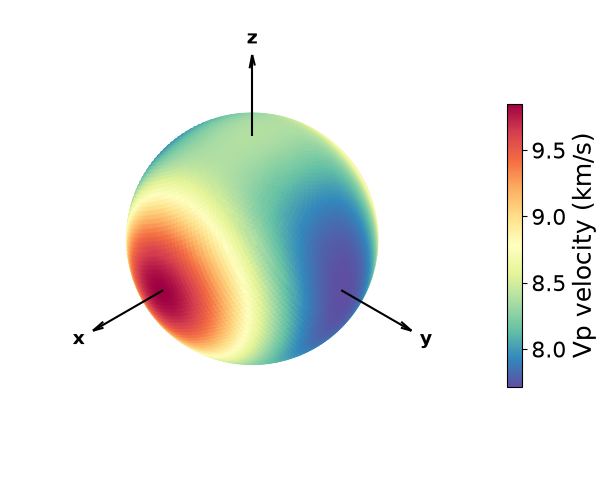

In [13]:
# plot to test
fig2, ax = plt.subplots(subplot_kw={"projection": "3d"}, constrained_layout=True)

speed = ax.scatter(wavevectors[:, 0], wavevectors[:, 1], wavevectors[:, 2], c=velocities["Vp_phase_kms"], cmap="Spectral_r")

# add small x, y, z direction arrows originating from the sphere's surface
axis_length = 0.75
origins = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
directions = origins  # arrows point radially outward from the surface

ax.quiver(
    origins[:, 0], origins[:, 1], origins[:, 2],
    directions[:, 0], directions[:, 1], directions[:, 2],
    length=axis_length, color="black", linewidth=1.5, arrow_length_ratio=0.15,
    zorder=10,
)

label_offset = 1 + axis_length * 1.2
for axis_label, (lx, ly, lz) in zip("xyz", origins * label_offset):
    ax.text(lx, ly, lz, axis_label, fontsize=14, fontweight="bold", ha="center", va="center", zorder=10)

# add color bar
cbar = fig2.colorbar(speed, ax=ax, shrink=0.6, location="right")
cbar.set_label("Vp velocity (km/s)", fontsize=18)
cbar.ax.tick_params(labelsize=16)

# tweak plot
ax.axis("off")
ax.set_box_aspect([1, 1, 1])  # enforce equal aspect ratio
# isometric view so all three direction arrows are visible without foreshortening
ax.view_init(elev=np.degrees(np.arctan(1 / np.sqrt(2))), azim=45)


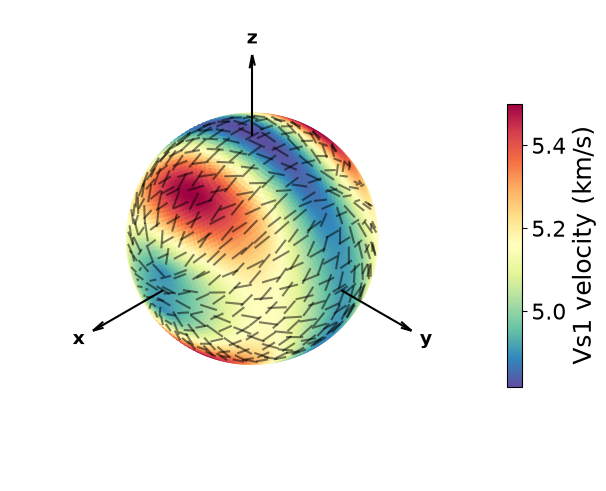

In [14]:
# plot to test
fig3, ax = plt.subplots(subplot_kw={"projection": "3d"}, constrained_layout=True)

speed = ax.scatter(
    wavevectors[:, 0],
    wavevectors[:, 1],
    wavevectors[:, 2],
    c=velocities["Vs1_phase_kms"],
    cmap="Spectral_r",
)

# S-wave polarizations (unsigned, so centred on the surface point)
ax.quiver(
    *wavevectors[subset].T,
    *polarization[subset, 1].T,
    color="black",
    pivot="middle",
    length=0.15,
    arrow_length_ratio=0,
    label="S1-wave",
    alpha=0.5
)

# Show reference frame ==================================================
# add small x, y, z direction arrows originating from the sphere's surface
axis_length = 0.75
origins = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
directions = origins  # arrows point radially outward from the surface

ax.quiver(
    origins[:, 0],
    origins[:, 1],
    origins[:, 2],
    directions[:, 0],
    directions[:, 1],
    directions[:, 2],
    length=axis_length,
    color="black",
    linewidth=1.5,
    arrow_length_ratio=0.15,
    zorder=10,
)

label_offset = 1 + axis_length * 1.2
for axis_label, (lx, ly, lz) in zip("xyz", origins * label_offset):
    ax.text(
        lx,
        ly,
        lz,
        axis_label,
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
        zorder=10,
    )

# add color bar ==================================================
cbar = fig3.colorbar(speed, ax=ax, shrink=0.6, location="right")
cbar.set_label("Vs1 velocity (km/s)", fontsize=18)
cbar.ax.tick_params(labelsize=16)

# tweak plot ==================================================
ax.axis("off")
ax.set_box_aspect([1, 1, 1])  # enforce equal aspect ratio
# isometric view so all three direction arrows are visible without foreshortening
ax.view_init(elev=np.degrees(np.arctan(1 / np.sqrt(2))), azim=45)

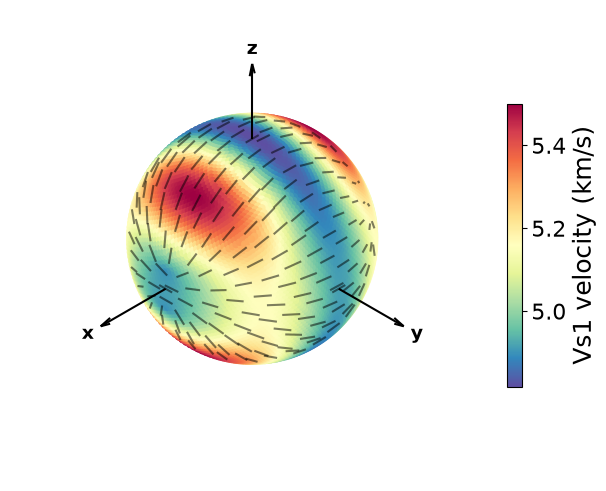

In [15]:
# fig3b: same as fig3 but hiding the polarization arrows on the back
# of the sphere (culled_quiver from pyrockwave.plotting.plots)
fig3b, ax = plt.subplots(subplot_kw={"projection": "3d"}, constrained_layout=True)

# Set the projection and view BEFORE plotting: culled_quiver evaluates
# arrow visibility for the axes' current camera position ("ortho" makes
# the visibility test exact). In interactive backends the arrows are
# re-culled automatically after each rotation.
ax.set_proj_type("ortho")
ax.view_init(elev=np.degrees(np.arctan(1 / np.sqrt(2))), azim=45)

speed = ax.scatter(
    wavevectors[:, 0],
    wavevectors[:, 1],
    wavevectors[:, 2],
    c=velocities["Vs1_phase_kms"],
    cmap="Spectral_r",
)

# S-wave polarizations, camera-facing hemisphere only
culled_quiver(
    ax,
    wavevectors[subset],
    polarization[subset, 1],
    color="black",
    pivot="middle",
    length=0.15,
    arrow_length_ratio=0,
    label="S1-wave",
    alpha=0.5,
)

# Show reference frame ==================================================
# add small x, y, z direction arrows originating from the sphere's surface
axis_length = 0.75
origins = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
directions = origins  # arrows point radially outward from the surface

ax.quiver(
    origins[:, 0],
    origins[:, 1],
    origins[:, 2],
    directions[:, 0],
    directions[:, 1],
    directions[:, 2],
    length=axis_length,
    color="black",
    linewidth=1.5,
    arrow_length_ratio=0.15,
    zorder=10,
)

label_offset = 1 + axis_length * 1.2
for axis_label, (lx, ly, lz) in zip("xyz", origins * label_offset):
    ax.text(
        lx,
        ly,
        lz,
        axis_label,
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
        zorder=10,
    )

# add color bar ==================================================
cbar = fig3b.colorbar(speed, ax=ax, shrink=0.6, location="right")
cbar.set_label("Vs1 velocity (km/s)", fontsize=18)
cbar.ax.tick_params(labelsize=16)

# tweak plot ==================================================
ax.axis("off")
ax.set_box_aspect([1, 1, 1])  # enforce equal aspect ratio

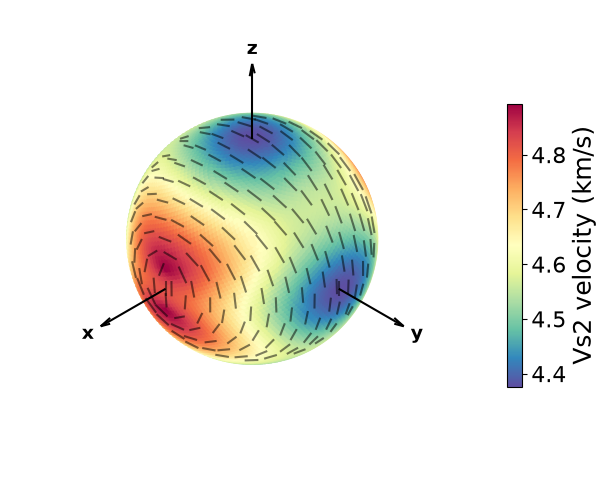

In [16]:
# fig4b: same as fig4 but hiding the polarization arrows on the back
# of the sphere (culled_quiver from pyrockwave.plotting.plots)
fig4b, ax = plt.subplots(subplot_kw={"projection": "3d"}, constrained_layout=True)

# Set the projection and view BEFORE plotting: culled_quiver evaluates
# arrow visibility for the axes' current camera position ("ortho" makes
# the visibility test exact). In interactive backends the arrows are
# re-culled automatically after each rotation.
ax.set_proj_type("ortho")
ax.view_init(elev=np.degrees(np.arctan(1 / np.sqrt(2))), azim=45)

speed = ax.scatter(
    wavevectors[:, 0],
    wavevectors[:, 1],
    wavevectors[:, 2],
    c=velocities["Vs2_phase_kms"],
    cmap="Spectral_r",
)

# S-wave polarizations, camera-facing hemisphere only
culled_quiver(
    ax,
    wavevectors[subset],
    polarization[subset, 0],
    color="black",
    pivot="middle",
    length=0.15,
    arrow_length_ratio=0,
    label="S2-wave",
    alpha=0.5,
)

# add small x, y, z direction arrows originating from the sphere's surface
axis_length = 0.75
origins = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
directions = origins  # arrows point radially outward from the surface

ax.quiver(
    origins[:, 0],
    origins[:, 1],
    origins[:, 2],
    directions[:, 0],
    directions[:, 1],
    directions[:, 2],
    length=axis_length,
    color="black",
    linewidth=1.5,
    arrow_length_ratio=0.15,
    zorder=10,
)

label_offset = 1 + axis_length * 1.2
for axis_label, (lx, ly, lz) in zip("xyz", origins * label_offset):
    ax.text(
        lx,
        ly,
        lz,
        axis_label,
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
        zorder=10,
    )

# add color bar
cbar = fig4b.colorbar(speed, ax=ax, shrink=0.6, location="right")
cbar.set_label("Vs2 velocity (km/s)", fontsize=18)
cbar.ax.tick_params(labelsize=16)

# tweak plot
ax.axis("off")
ax.set_box_aspect([1, 1, 1])  # enforce equal aspect ratio

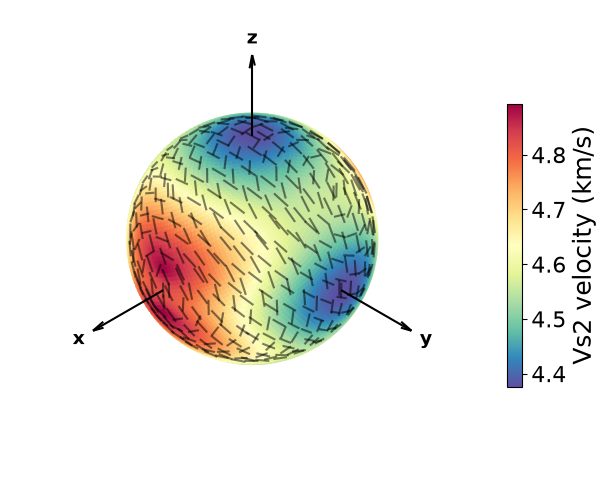

In [17]:
# plot to test
fig4, ax = plt.subplots(subplot_kw={"projection": "3d"}, constrained_layout=True)

speed = ax.scatter(
    wavevectors[:, 0],
    wavevectors[:, 1],
    wavevectors[:, 2],
    c=velocities["Vs2_phase_kms"],
    cmap="Spectral_r",
)

# S-wave polarizations (unsigned, so centred on the surface point)
ax.quiver(
    *wavevectors[subset].T,
    *polarization[subset, 0].T,
    color="black",
    pivot="middle",
    length=0.15,
    arrow_length_ratio=0,
    label="S2-wave",
    alpha=0.5,
)

# add small x, y, z direction arrows originating from the sphere's surface
axis_length = 0.75
origins = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
directions = origins  # arrows point radially outward from the surface


ax.quiver(
    origins[:, 0],
    origins[:, 1],
    origins[:, 2],
    directions[:, 0],
    directions[:, 1],
    directions[:, 2],
    length=axis_length,
    color="black",
    linewidth=1.5,
    arrow_length_ratio=0.15,
    zorder=10,
)

label_offset = 1 + axis_length * 1.2
for axis_label, (lx, ly, lz) in zip("xyz", origins * label_offset):
    ax.text(
        lx,
        ly,
        lz,
        axis_label,
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
        zorder=10,
    )

# add color bar
cbar = fig4.colorbar(speed, ax=ax, shrink=0.6, location="right")
cbar.set_label("Vs2 velocity (km/s)", fontsize=18)
cbar.ax.tick_params(labelsize=16)

# tweak plot
ax.axis("off")
ax.set_box_aspect([1, 1, 1])  # enforce equal aspect ratio
# isometric view so all three direction arrows are visible without foreshortening
ax.view_init(elev=np.degrees(np.arctan(1 / np.sqrt(2))), azim=45)


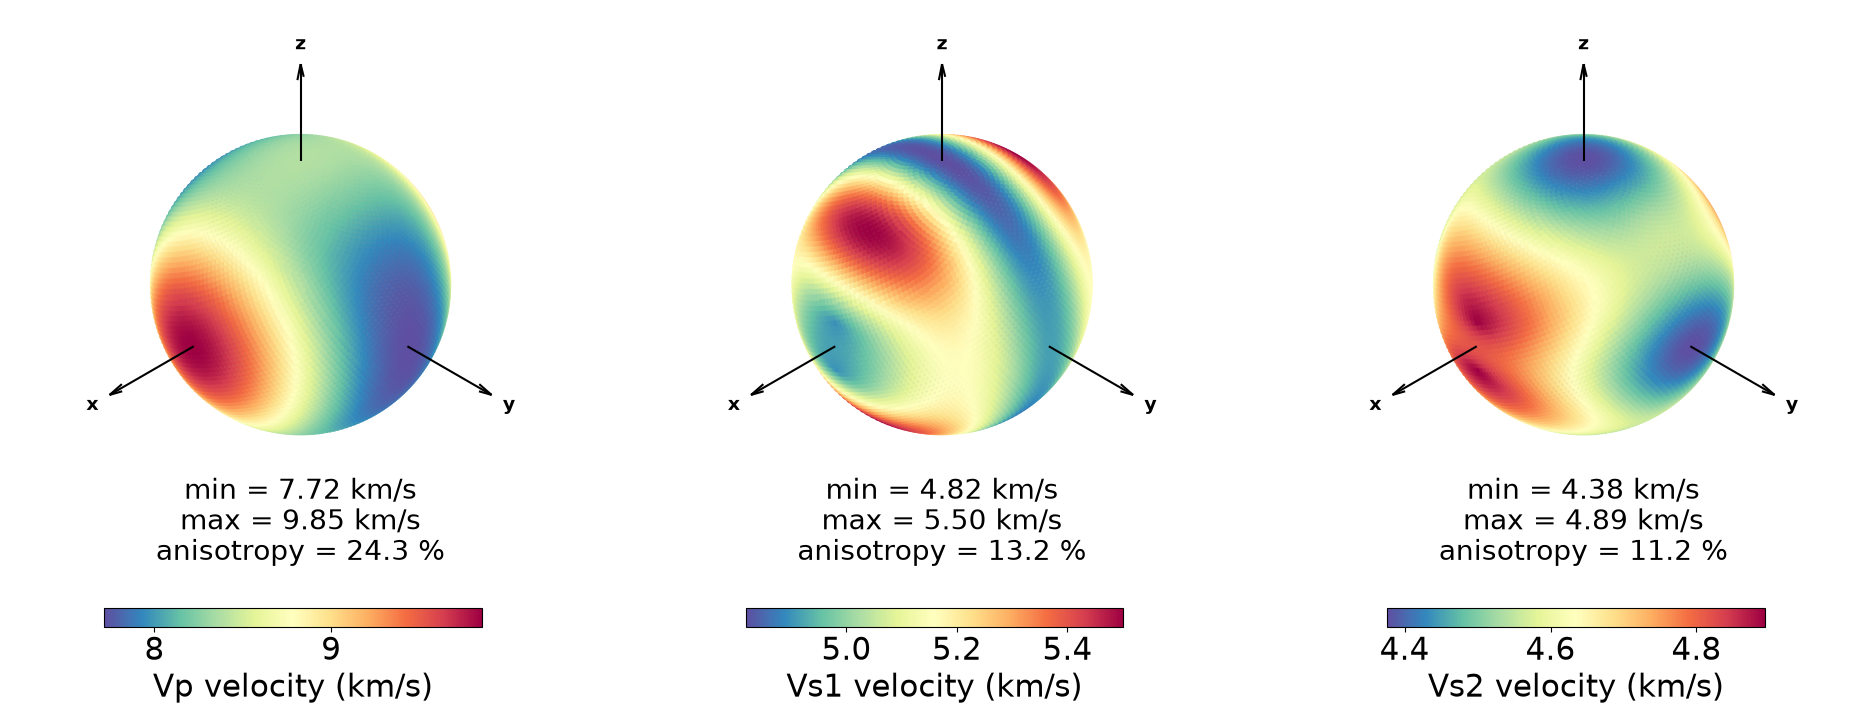

In [18]:
# plot to test
fig5, (ax1, ax2, ax3) = plt.subplots(
    figsize=(6.4*3, 7.),
    ncols=3,
    subplot_kw={"projection": "3d"},
    constrained_layout=True
)

# ===========================================================================
# Vp (axe 1)
# ===========================================================================
Vp = ax1.scatter(
    wavevectors[:, 0],
    wavevectors[:, 1],
    wavevectors[:, 2],
    c=velocities["Vp_phase_kms"],
    cmap="Spectral_r",
)

# add small x, y, z direction arrows originating from the sphere's surface
axis_length = 0.75
origins = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
directions = origins  # arrows point radially outward from the surface

ax1.quiver(
    origins[:, 0],
    origins[:, 1],
    origins[:, 2],
    directions[:, 0],
    directions[:, 1],
    directions[:, 2],
    length=axis_length,
    color="black",
    linewidth=1.5,
    arrow_length_ratio=0.15,
    zorder=10,
)

label_offset = 1 + axis_length * 1.2
for axis_label, (lx, ly, lz) in zip("xyz", origins * label_offset):
    ax1.text(
        lx,
        ly,
        lz,
        axis_label,
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
        zorder=10,
    )

# add color bar
cbar1 = fig5.colorbar(Vp, ax=ax1, shrink=0.6, location="bottom")
cbar1.set_label("Vp velocity (km/s)", fontsize=22)
cbar1.ax.tick_params(labelsize=22)

# show relevant info
Vp_min = velocities["Vp_phase_kms"].min()
Vp_max = velocities["Vp_phase_kms"].max()
Vp_anis = 200 * (Vp_max - Vp_min) / (Vp_max + Vp_min)
ax1.text2D(x=0, y=-0.07, s=f"min = {Vp_min:.2f} km/s", fontsize=20, ha="center")
ax1.text2D(x=0, y=-0.08, s=f"max = {Vp_max:.2f} km/s", fontsize=20, ha="center")
ax1.text2D(x=0, y=-0.09, s=f"anisotropy = {Vp_anis:.1f} %", fontsize=20, ha="center")


# tweak plot
ax1.axis("off")
ax1.set_box_aspect([1, 1, 1])  # enforce equal aspect ratio
# isometric view so all three direction arrows are visible without foreshortening
ax1.view_init(elev=np.degrees(np.arctan(1 / np.sqrt(2))), azim=45)

# ax1.set_title(label="phase Vp (km/s)", loc="center", fontsize=20)

# ===========================================================================
# Vs1 (axe 2)
# ===========================================================================

Vs1 = ax2.scatter(
    wavevectors[:, 0],
    wavevectors[:, 1],
    wavevectors[:, 2],
    c=velocities["Vs1_phase_kms"],
    cmap="Spectral_r",
)

# add small x, y, z direction arrows originating from the sphere's surface
axis_length = 0.75
origins = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
directions = origins  # arrows point radially outward from the surface

ax2.quiver(
    origins[:, 0],
    origins[:, 1],
    origins[:, 2],
    directions[:, 0],
    directions[:, 1],
    directions[:, 2],
    length=axis_length,
    color="black",
    linewidth=1.5,
    arrow_length_ratio=0.15,
    zorder=10,
)

label_offset = 1 + axis_length * 1.2
for axis_label, (lx, ly, lz) in zip("xyz", origins * label_offset):
    ax2.text(
        lx,
        ly,
        lz,
        axis_label,
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
        zorder=10,
    )

# add color bar
cbar2 = fig5.colorbar(Vs1, ax=ax2, shrink=0.6, location="bottom")
cbar2.set_label("Vs1 velocity (km/s)", fontsize=22)
cbar2.ax.tick_params(labelsize=22)

# show relevant info
Vs1_min = velocities["Vs1_phase_kms"].min()
Vs1_max = velocities["Vs1_phase_kms"].max()
Vs1_anis = 200 * (Vs1_max - Vs1_min) / (Vs1_max + Vs1_min)
ax2.text2D(x=0, y=-0.07, s=f"min = {Vs1_min:.2f} km/s", fontsize=20, ha="center")
ax2.text2D(x=0, y=-0.08, s=f"max = {Vs1_max:.2f} km/s", fontsize=20, ha="center")
ax2.text2D(x=0, y=-0.09, s=f"anisotropy = {Vs1_anis:.1f} %", fontsize=20, ha="center")

# tweak plot
ax2.axis("off")
ax2.set_box_aspect([1, 1, 1])  # enforce equal aspect ratio
# isometric view so all three direction arrows are visible without foreshortening
ax2.view_init(elev=np.degrees(np.arctan(1 / np.sqrt(2))), azim=45)

# ax2.set_title(label="phase Vs1 (km/s)", loc="center", fontsize=20)

# ===========================================================================
# Vs2 (axe 3)
# ===========================================================================

Vs2 = ax3.scatter(
    wavevectors[:, 0],
    wavevectors[:, 1],
    wavevectors[:, 2],
    c=velocities["Vs2_phase_kms"],
    cmap="Spectral_r",
)

# add small x, y, z direction arrows originating from the sphere's surface
axis_length = 0.75
origins = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
directions = origins  # arrows point radially outward from the surface

ax3.quiver(
    origins[:, 0],
    origins[:, 1],
    origins[:, 2],
    directions[:, 0],
    directions[:, 1],
    directions[:, 2],
    length=axis_length,
    color="black",
    linewidth=1.5,
    arrow_length_ratio=0.15,
    zorder=10,
)

label_offset = 1 + axis_length * 1.2
for axis_label, (lx, ly, lz) in zip("xyz", origins * label_offset):
    ax3.text(
        lx,
        ly,
        lz,
        axis_label,
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
        zorder=10,
    )

# add color bar
cbar3 = fig5.colorbar(Vs2, ax=ax3, shrink=0.6, location="bottom")
cbar3.set_label("Vs2 velocity (km/s)", fontsize=22)
cbar3.ax.tick_params(labelsize=22)

# show relevant info
Vs2_min = velocities['Vs2_phase_kms'].min()
Vs2_max = velocities['Vs2_phase_kms'].max()
Vs2_anis = 200 * (Vs2_max - Vs2_min) / (Vs2_max + Vs2_min)
ax3.text2D(x=0, y=-0.07, s=f"min = {Vs2_min:.2f} km/s", fontsize=20, ha="center")
ax3.text2D(x=0, y=-0.08, s=f"max = {Vs2_max:.2f} km/s", fontsize=20, ha="center")
ax3.text2D(x=0, y=-0.09, s=f"anisotropy = {Vs2_anis:.1f} %", fontsize=20, ha="center")

# tweak plot
ax3.axis("off")
ax3.set_box_aspect([1, 1, 1])  # enforce equal aspect ratio
# isometric view so all three direction arrows are visible without foreshortening
ax3.view_init(elev=np.degrees(np.arctan(1 / np.sqrt(2))), azim=45)

# ax3.set_title(label="phase Vs2 (km/s)", loc="center", fontsize=20)

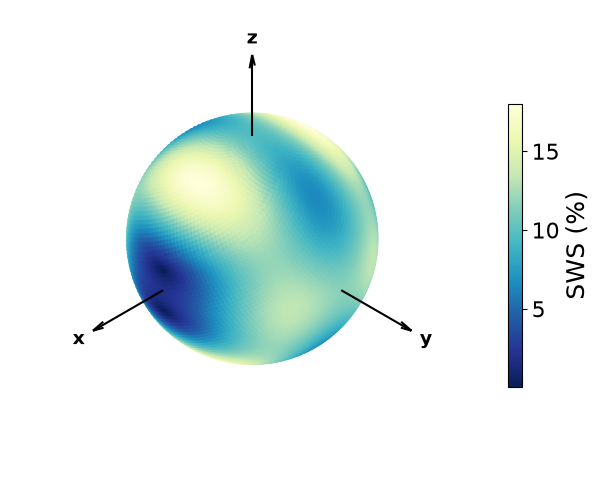

In [19]:
# plot to test
fig6, ax = plt.subplots(subplot_kw={"projection": "3d"}, constrained_layout=True)

speed = ax.scatter(
    wavevectors[:, 0],
    wavevectors[:, 1],
    wavevectors[:, 2],
    c=velocities["SWS_perc"],
    cmap="YlGnBu_r",
)

# add small x, y, z direction arrows originating from the sphere's surface
axis_length = 0.75
origins = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
directions = origins  # arrows point radially outward from the surface

ax.quiver(
    origins[:, 0],
    origins[:, 1],
    origins[:, 2],
    directions[:, 0],
    directions[:, 1],
    directions[:, 2],
    length=axis_length,
    color="black",
    linewidth=1.5,
    arrow_length_ratio=0.15,
    zorder=10,
)

label_offset = 1 + axis_length * 1.2
for axis_label, (lx, ly, lz) in zip("xyz", origins * label_offset):
    ax.text(
        lx,
        ly,
        lz,
        axis_label,
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
        zorder=10,
    )

# add color bar
cbar = fig6.colorbar(speed, ax=ax, shrink=0.6, location="right")
cbar.set_label("SWS (%)", fontsize=18)
cbar.ax.tick_params(labelsize=16)

# tweak plot
ax.axis("off")
ax.set_box_aspect([1, 1, 1])  # enforce equal aspect ratio
# isometric view so all three direction arrows are visible without foreshortening
ax.view_init(elev=np.degrees(np.arctan(1 / np.sqrt(2))), azim=45)


TODO